This model will be for the RGB branch and make use of the DINOv2 transformer as the backbone. The difference from model 3 V3 is that this one makes use of data augmentation (only slight with small zooms and cropping with a slight distortion) this is to make the model more generalizable, however the images already have a slightly different framing and lighting so it might not make much of a difference.

The notebook also removes two problematic dishes which was identified when looking through the entire dataset.

Prerequisits

In [ ]:
!pip install -q pandas numpy
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Libraries

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

Paths

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")
METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_split_metadata.csv")

OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_3_V5_DINOv2_RGB_only_data_aug")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = OUTPUT_DIR / "prep_files"
PREP_DIR.mkdir(parents=True, exist_ok=True)

BAD_DISH_IDS = {
    "dish_1559172356",
    "dish_1564588719",
}

Reading metadata and image data

In [ ]:
df = pd.read_csv(METADATA_CSV)

print(df.head())
print(df["split"].value_counts())
print("Total rows before exclusion:", len(df))
print("Unique dishes before exclusion:", df["dish_id"].nunique())

df = df[~df["dish_id"].astype(str).isin(BAD_DISH_IDS)].copy()

print("\nTotal rows after exclusion:", len(df))
print("Unique dishes after exclusion:", df["dish_id"].nunique())
print("Excluded dishes:", BAD_DISH_IDS)

           dish_id  total_carb split source_cafe
0  dish_1556575327      10.618  test       cafe1
1  dish_1557861216       0.000  test       cafe1
2  dish_1557862345       0.000  test       cafe1
3  dish_1557862696       3.850  test       cafe1
4  dish_1557862738       0.000  test       cafe1
split
train    2421
test      507
val       334
Name: count, dtype: int64
Total rows before exclusion: 3262
Unique dishes before exclusion: 3262

Total rows after exclusion: 3260
Unique dishes after exclusion: 3260
Excluded dishes: {'dish_1564588719', 'dish_1559172356'}


In [ ]:
df["rgb_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / str(d) / "overhead" / "rgb.png")
)

df["rgb_exists"] = df["rgb_path"].apply(lambda p: Path(p).exists())

print("Missing RGB images:", (~df["rgb_exists"]).sum())

Missing RGB images: 0


In [ ]:
def file_size_or_minus1(path_str):
    p = Path(path_str)
    try:
        return p.stat().st_size
    except:
        return -1

df["rgb_size"] = df["rgb_path"].apply(file_size_or_minus1)

print("Empty RGB files:", (df["rgb_size"] <= 0).sum())

df = df[
    (df["rgb_exists"]) &
    (df["rgb_size"] > 0)
].copy()

print("\nRemaining samples after filtering:")
print(df["split"].value_counts())
print("Total remaining:", len(df))

Empty RGB files: 0

Remaining samples after filtering:
split
train    2419
test      507
val       334
Name: count, dtype: int64
Total remaining: 3260


In [ ]:
train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
val_df   = df[df["split"] == "val"].copy().reset_index(drop=True)
test_df  = df[df["split"] == "test"].copy().reset_index(drop=True)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2419
Val:   334
Test:  507


In [ ]:
train_csv = PREP_DIR / "train_rgb_only.csv"
val_csv   = PREP_DIR / "val_rgb_only.csv"
test_csv  = PREP_DIR / "test_rgb_only.csv"
full_csv  = PREP_DIR / "full_filtered_rgb_only.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)
df.to_csv(full_csv, index=False)

print("Saved:")
print(train_csv)
print(val_csv)
print(test_csv)
print(full_csv)

Saved:
/content/drive/MyDrive/Speciale/Models/Model_3_V5_DINOv2_RGB_only_data_aug/prep_files/train_rgb_only.csv
/content/drive/MyDrive/Speciale/Models/Model_3_V5_DINOv2_RGB_only_data_aug/prep_files/val_rgb_only.csv
/content/drive/MyDrive/Speciale/Models/Model_3_V5_DINOv2_RGB_only_data_aug/prep_files/test_rgb_only.csv
/content/drive/MyDrive/Speciale/Models/Model_3_V5_DINOv2_RGB_only_data_aug/prep_files/full_filtered_rgb_only.csv


SWITCH TO GPU FOR MODEL TRAINING

In [ ]:
!pip install -q keras-hub huggingface_hub

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import keras_hub

from huggingface_hub import notebook_login, HfApi

In [ ]:
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Settings

In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH  = 224
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

STAGE1_EPOCHS = 100
STAGE2_EPOCHS = 200

STAGE1_LR = 2e-4
STAGE2_LR = 5e-6

# ---------------------------------------------------------
# Possible DINO options starting with dinov2_large
# DINOv2:
#   "dinov2_small"
#   "dinov2_base"
#   "dinov2_large"
# ---------------------------------------------------------
BACKBONE_PRESET = "dinov2_large"

OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_3_V5_DINOv2_RGB_only_data_aug")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = OUTPUT_DIR / "prep_files"

train_csv = PREP_DIR / "train_rgb_only.csv"
val_csv   = PREP_DIR / "val_rgb_only.csv"
test_csv  = PREP_DIR / "test_rgb_only.csv"

Loading dataset

In [ ]:
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

display(train_df.head())

Train: 2419
Val:   334
Test:  507


,dish_id,total_carb,split,source_cafe,rgb_path,rgb_exists,rgb_size
0,dish_1556572657,2.268,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412129
1,dish_1556573514,1.219,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,432908
2,dish_1556575014,3.906,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,409854
3,dish_1556575083,5.760,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,396942
4,dish_1556575124,0.952,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,404314


In [ ]:
def load_rgb_image(rgb_path):
    image = tf.io.read_file(rgb_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize_with_pad(
        image,
        target_height=IMG_HEIGHT,
        target_width=IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    return image


def load_rgb_and_label(rgb_path, label):
    rgb = load_rgb_image(rgb_path)
    label = tf.cast(label, tf.float32)
    return {"rgb_input": rgb}, label


def make_dataset(dataframe, batch_size=16, shuffle=False):
    rgb_paths = dataframe["rgb_path"].values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((rgb_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.map(load_rgb_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds

In [ ]:
train_dataset = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
validation_dataset = make_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

for batch_inputs, batch_labels in train_dataset.take(1):
    print("RGB batch shape:", batch_inputs["rgb_input"].shape)
    print("Labels shape:   ", batch_labels.shape)

RGB batch shape: (16, 224, 224, 3)
Labels shape:    (16,)


Inspecting one image

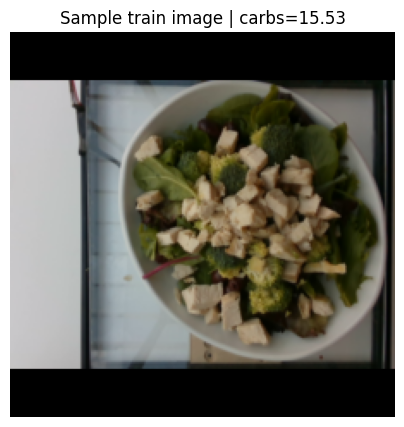

In [ ]:
for batch_inputs, batch_labels in train_dataset.take(1):
    sample_img = batch_inputs["rgb_input"][0].numpy().astype("uint8")
    sample_label = batch_labels[0].numpy()

plt.figure(figsize=(5, 5))
plt.imshow(sample_img)
plt.title(f"Sample train image | carbs={sample_label:.2f}")
plt.axis("off")
plt.show()

Loading backbone and image converter

In [ ]:
image_converter = keras_hub.layers.ImageConverter.from_preset(
    BACKBONE_PRESET,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
)

backbone = keras_hub.models.Backbone.from_preset(
    BACKBONE_PRESET,
    image_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
)

backbone.trainable = False

print("Using preset:", BACKBONE_PRESET)
print("Image size:", (IMG_HEIGHT, IMG_WIDTH))

Using preset: dinov2_large
Image size: (224, 224)


In [ ]:
def extract_backbone_tensor(x):
    if isinstance(x, dict):
        preferred_keys = [
            "sequence_output",
            "pooled_output",
            "encoder_output",
            "token_embeddings",
            "hidden_states"
        ]
        for key in preferred_keys:
            if key in x:
                return x[key]
        return list(x.values())[0]
    return x

Data augmentation settings

In [ ]:
data_augmentation = keras.Sequential(
    [
        layers.RandomZoom(
            height_factor=(-0.08, 0.05),
            width_factor=(-0.08, 0.05),
            fill_mode="nearest"
        ),
        layers.RandomTranslation(
            height_factor=0.03,
            width_factor=0.03,
            fill_mode="nearest"
        ),
        layers.RandomRotation(
            factor=0.04,
            fill_mode="nearest"
        ),
        layers.RandomContrast(0.08),
    ],
    name="light_data_augmentation"
)

Model architecture

In [ ]:
rgb_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

x = data_augmentation(rgb_input)

x = image_converter(x)
x = backbone(x)
x = extract_backbone_tensor(x)

if len(x.shape) == 3:
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D(name="token_pool")(x)
else:
    x = layers.LayerNormalization()(x)
    x = layers.Flatten()(x)

x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu", name="dense_64")(x)
output = layers.Dense(1, activation="linear", name="carb_output")(x)

model = keras.Model(
    inputs={"rgb_input": rgb_input},
    outputs=output,
    name="rgb_only_dino_vit_regressor"
)

model.summary()

Model: "rgb_only_dino_vit_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ light_data_augmentation         │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_image_converter          │ (None, 224, 224, 3)    │             0 │
│ (DINOV2ImageConverter)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_backbone                 │ (None, 257, 1024)      │   304,631,808 │
│ (DINOV2Backbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 257, 1024)      │         2,048 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_pool                      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,912,769 (1.14 GB)

 Trainable params: 280,961 (1.07 MB)

 Non-trainable params: 304,631,808 (1.13 GB)

Settings for training

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False
)

In [ ]:
stage1_best_path = OUTPUT_DIR / "best_model_stage1.weights.h5"

stage1_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(stage1_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=50,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=35,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

In [ ]:
history_stage1 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=STAGE1_EPOCHS,
    callbacks=stage1_callbacks
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 549.4936 - mae: 13.8575 - mse: 549.4936
Epoch 1: val_loss improved from None to 164.47125, saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V5_DINOv2_RGB_only_data_aug/best_model_stage1.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V5_DINOv2_RGB_only_data_aug/best_model_stage1.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - loss: 542.9865 - mae: 12.5626 - mse: 542.9865 - val_loss: 164.4713 - val_mae: 9.5594 - val_mse: 164.4713 - learning_rate: 2.0000e-04
Epoch 2/100
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - loss: 421.6117 - mae: 10.6591 - mse: 421.6117
Epoch 2: val_loss improved from 164.47125 to 106.47690, saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V5_DINOv2_RGB_only_data_aug/best_model_stage1.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V5_DINOv2_RGB_only_data_aug/best_model_stage1.weights.h5
152/152

Evaluating stage 1

In [ ]:
model.load_weights(str(stage1_best_path))

stage1_test_results = model.evaluate(test_dataset, return_dict=True, verbose=1)

print("Stage 1 test results:")
for k, v in stage1_test_results.items():
    print(f"{k}: {v:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - loss: 85.0733 - mae: 6.1757 - mse: 85.0733
Stage 1 test results:
loss: 85.0733
mae: 6.1757
mse: 85.0733


Stage 2 (30% of backbone unfrozen)

In [ ]:
model.load_weights(str(stage1_best_path))

backbone.trainable = True

num_layers = len(backbone.layers)
freeze_until = int(num_layers * 0.70)

for i, layer in enumerate(backbone.layers):
    layer.trainable = (i >= freeze_until)

print(f"Total backbone layers: {num_layers}")
print(f"Frozen layers:         {freeze_until}")
print(f"Trainable layers:      {num_layers - freeze_until}")

trainable_count = 0
frozen_count = 0
for layer in backbone.layers:
    if layer.trainable:
        trainable_count += 1
    else:
        frozen_count += 1

print("Backbone trainable layers:", trainable_count)
print("Backbone frozen layers:   ", frozen_count)

Total backbone layers: 4
Frozen layers:         2
Trainable layers:      2
Backbone trainable layers: 2
Backbone frozen layers:    2


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE2_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False
)

In [ ]:
stage2_best_path = OUTPUT_DIR / "best_model_stage2.weights.h5"

stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(stage2_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=100,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=75,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]

In [ ]:
history_stage2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=STAGE2_EPOCHS,
    callbacks=stage2_callbacks
)

Epoch 1/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - loss: 267.1727 - mae: 7.8315 - mse: 267.1727
Epoch 1: val_loss improved from None to 87.18526, saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V5_DINOv2_RGB_only_data_aug/best_model_stage2.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V5_DINOv2_RGB_only_data_aug/best_model_stage2.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 144s 494ms/step - loss: 388.1768 - mae: 7.6756 - mse: 388.1768 - val_loss: 87.1853 - val_mae: 6.3463 - val_mse: 87.1853 - learning_rate: 5.0000e-06
Epoch 2/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - loss: 114.8080 - mae: 5.9525 - mse: 114.8080
Epoch 2: val_loss did not improve from 87.18526
152/152 ━━━━━━━━━━━━━━━━━━━━ 63s 416ms/step - loss: 351.0859 - mae: 6.5489 - mse: 351.0859 - val_loss: 97.5921 - val_mae: 6.7947 - val_mse: 97.5921 - learning_rate: 5.0000e-06
Epoch 3/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - loss: 177.7007 - mae: 6.1849 

Evaluating stage 2

In [ ]:
model.load_weights(str(stage2_best_path))

stage2_test_results = model.evaluate(test_dataset, return_dict=True, verbose=1)

print("Stage 2 test results:")
for k, v in stage2_test_results.items():
    print(f"{k}: {v:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 70.5732 - mae: 5.0766 - mse: 70.5732
Stage 2 test results:
loss: 70.5732
mae: 5.0766
mse: 70.5732


Visualizing training and validation curves

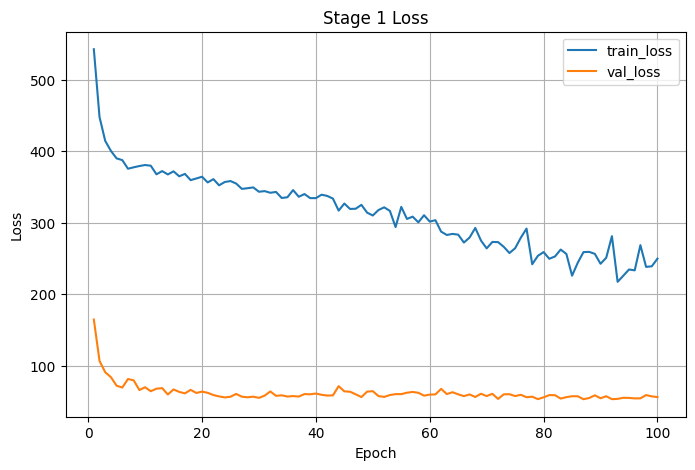

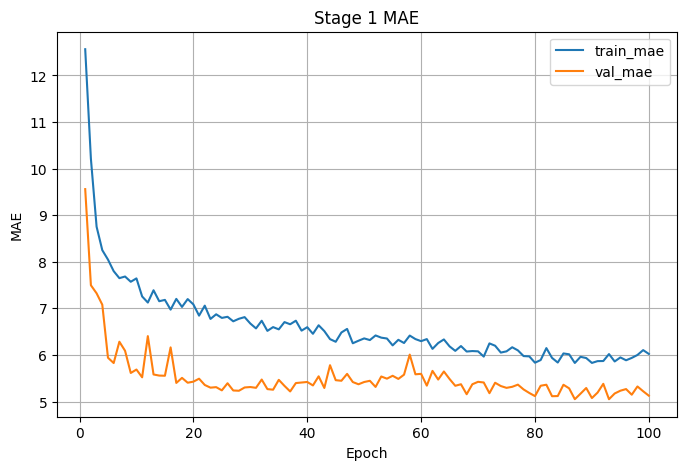

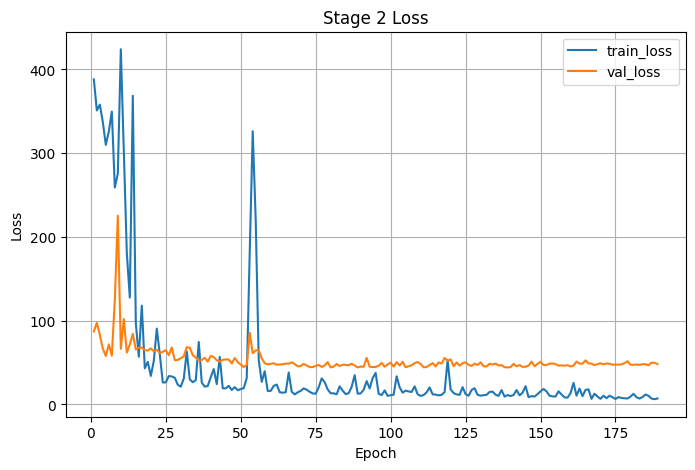

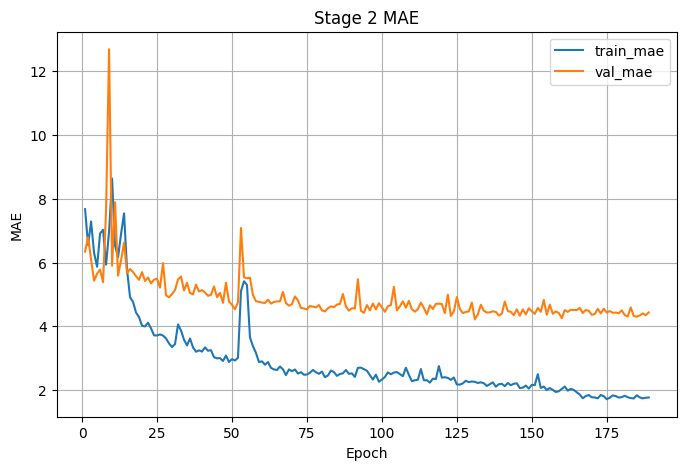

In [ ]:
def plot_history(history, title_prefix=""):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["loss"], label="train_loss")
    plt.plot(epochs, hist["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["mae"], label="train_mae")
    plt.plot(epochs, hist["val_mae"], label="val_mae")
    plt.title(f"{title_prefix} MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history_stage1, "Stage 1")
plot_history(history_stage2, "Stage 2")

Creating comparison dataframe

In [ ]:
comparison_df = pd.DataFrame([
    {
        "stage": "stage_1",
        "test_loss": stage1_test_results.get("loss"),
        "test_mae": stage1_test_results.get("mae"),
        "test_mse": stage1_test_results.get("mse"),
    },
    {
        "stage": "stage_2",
        "test_loss": stage2_test_results.get("loss"),
        "test_mae": stage2_test_results.get("mae"),
        "test_mse": stage2_test_results.get("mse"),
    }
])

display(comparison_df)
comparison_df.to_csv(OUTPUT_DIR / "stage_test_comparison.csv", index=False)

,stage,test_loss,test_mae,test_mse
0,stage_1,85.073273,6.175679,85.073273
1,stage_2,70.573151,5.076594,70.573151


PMAE calculation helper

In [ ]:
def compute_pmae(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)

    denom = np.maximum(np.abs(y_true), eps)
    pmae = np.mean(np.abs(y_true - y_pred) / denom) * 100.0
    return float(pmae)

Calculating PMAE and other metrics

In [ ]:
model.load_weights(str(stage2_best_path))

test_eval_df = test_df.copy().reset_index(drop=True)

preds = model.predict(test_dataset, verbose=1).reshape(-1)

test_eval_df["prediction"] = preds
test_eval_df["abs_error"] = np.abs(test_eval_df["total_carb"] - test_eval_df["prediction"])
test_eval_df["signed_error"] = test_eval_df["prediction"] - test_eval_df["total_carb"]

stage2_pmae = compute_pmae(
    y_true=test_eval_df["total_carb"].values,
    y_pred=test_eval_df["prediction"].values
)

print(f"Stage 2 PMAE: {stage2_pmae:.2f}%")

pred_csv = OUTPUT_DIR / "test_predictions_stage2.csv"
test_eval_df.to_csv(pred_csv, index=False)

print("Saved:", pred_csv)
display(test_eval_df.head())

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(16, 224, 224, 3))
  warnings.warn(msg)


31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 205ms/step
Stage 2 PMAE: 108554376.00%
Saved: /content/drive/MyDrive/Speciale/Models/Model_3_V5_DINOv2_RGB_only_data_aug/test_predictions_stage2.csv


,dish_id,total_carb,split,source_cafe,rgb_path,rgb_exists,rgb_size,prediction,abs_error,signed_error
0,dish_1556575327,10.618,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,548259,13.465687,2.847687,2.847687
1,dish_1557861216,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,353804,1.323529,1.323529,1.323529
2,dish_1557862345,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,407501,0.595602,0.595602,0.595602
3,dish_1557862696,3.850,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,391780,5.512854,1.662854,1.662854
4,dish_1557862738,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412017,1.692852,1.692852,1.692852


Wrong PMAE calculation

Top 10 best and worst dishes

In [ ]:
best_10 = test_eval_df.sort_values("abs_error", ascending=True).head(10)
worst_10 = test_eval_df.sort_values("abs_error", ascending=False).head(10)

print("Top 10 best predictions:")
display(best_10[["dish_id", "total_carb", "prediction", "abs_error", "signed_error"]])

print("Top 10 worst predictions:")
display(worst_10[["dish_id", "total_carb", "prediction", "abs_error", "signed_error"]])

best_10.to_csv(OUTPUT_DIR / "top10_best_predictions_stage2.csv", index=False)
worst_10.to_csv(OUTPUT_DIR / "top10_worst_predictions_stage2.csv", index=False)

Top 10 best predictions:


,dish_id,total_carb,prediction,abs_error,signed_error
335,dish_1563909469,2.248366,2.240766,0.007600,-0.007600
478,dish_1566850099,4.140735,4.166437,0.025702,0.025702
120,dish_1559239256,15.360000,15.387938,0.027938,0.027938
485,dish_1566920304,3.990000,3.957705,0.032295,-0.032295
81,dish_1558639412,7.760000,7.720070,0.039930,-0.039930
229,dish_1561662926,11.059766,11.017115,0.042651,-0.042651
395,dish_1565035774,12.250000,12.206770,0.043230,-0.043230
266,dish_1562691000,27.178827,27.235094,0.056267,0.056267
439,dish_1565986733,9.926110,10.026540,0.100430,0.100430
198,dish_1561405332,3.710000,3.608342,0.101658,-0.101658


Top 10 worst predictions:


,dish_id,total_carb,prediction,abs_error,signed_error
177,dish_1560800988,61.249092,18.428127,42.820965,-42.820965
178,dish_1560801020,61.690983,20.404688,41.286295,-41.286295
179,dish_1560801041,63.245892,26.346991,36.898901,-36.898901
149,dish_1560367952,45.956913,11.379942,34.576971,-34.576971
150,dish_1560367980,47.243912,13.537000,33.706912,-33.706912
446,dish_1566328805,85.054001,52.151402,32.902599,-32.902599
447,dish_1566328831,85.809998,54.014526,31.795472,-31.795472
247,dish_1562009934,62.243580,31.447714,30.795866,-30.795866
445,dish_1566328776,78.293999,47.617851,30.676148,-30.676148
451,dish_1566414412,57.062336,26.618757,30.443579,-30.443579


Saving final model

In [ ]:
model.load_weights(str(stage2_best_path))

final_keras_path = OUTPUT_DIR / "final_model.keras"
model.save(final_keras_path)

export_dir = OUTPUT_DIR / "saved_model_export"
model.export(export_dir)

print("Saved final .keras model to:", final_keras_path)
print("Saved exported model to:", export_dir)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


Saved artifact at '/content/drive/MyDrive/Speciale/Models/Model_3_V5_DINOv2_RGB_only_data_aug/saved_model_export'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['rgb_input', TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='rgb_input')]]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140407403959824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140407400548688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140407400550608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140407400551184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140407400559632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140407400560784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140407400559056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140407400559824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140407400559248: TensorSpec(shape=(), dtype=tf.resource, na